## Imports and project setup

Import analysis libraries and project modules from `Synthetic/src`, then set the initial NumPy random seed.

Each complete run creates a timestamped folder under `local/results/`. All figures (PNG and PDF), per-seed/per-step numerical results, multi-seed summaries, and settings are saved together. Run the notebook from top to bottom; the final cell writes `all_results.csv` and marks the run complete. Re-running the setup cell starts a new folder.


In [1]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import yaml
import random
from collections import defaultdict
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple
import glob
import joblib

# Load project modules from Synthetic/src.
import sys
from pathlib import Path

src_path = Path("Synthetic/src")
if not src_path.is_dir():
    src_path = Path("../Synthetic/src")
src_path = src_path.resolve()
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from simulator import Bank, Agent as SimAgentBase, run_simulation
from evaluation import compute_statistics
from fair_model import FairModel
from activity_fair_model import ActivityAwareFairModel
from baselines import LR, CvxFairModel, EOFairModel
from utils import combine_tuples_active_only

FAIRNESS_CLIP = 0.05  # Shared by both LCF optimizers and all fairness evaluation.
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
# Execute this setup cell once per complete run to create a unique output directory.
from run_results import RunResults
run_results = RunResults(src_path.parents[1] / "local" / "results")
print(f"Run outputs: {run_results.folder}")

_compute_statistics = compute_statistics
DIAGNOSTIC_ESTIMATOR = "probability_policy_repayment_labels"
def compute_statistics(*args, **kwargs):
    kwargs.setdefault("clip", FAIRNESS_CLIP)
    records = _compute_statistics(*args, **kwargs)
    if run_results.last_context is not None:
        for record in records:
            for metric, value in record.items():
                if metric != 'step':
                    run_results.add(run_results.last_context,
                                    'diagnostic_' + DIAGNOSTIC_ESTIMATOR,
                                    metric, value, step=record['step'])
    return records


Run outputs: /Users/jh22215/Documents/GitHub/Delayed-Fairness-Project/local/results/20260917T170632_004886Z_9d3261


## Load the BAF datasets

Read all six local CSV files into `dataframes`, define dataset aliases, and create working copies of Base, Variant I, and Variant II.


In [2]:
# Reuse src_path, Path, and pd from the setup cell.
base_path = src_path.parents[1] / "local"
extension = "csv"

datasets_paths = {
    name: base_path / f"{name}.{extension}"
    for name in ["Base", "Variant I", "Variant II", "Variant III", "Variant IV", "Variant V"]
}

def read_dataset(path, ext=extension):
    if ext == "csv":
        return pd.read_csv(path)
    elif ext == "parquet":
        return pd.read_parquet(path)
    else:
        raise ValueError(f"Unsupported file extension: {ext}")

def get_variant(path):
    return Path(path).stem

data_paths = list(datasets_paths.values())
dataframes = {get_variant(path): read_dataset(path) for path in data_paths}
print(f"Loaded datasets: {list(dataframes.keys())}")

# Rename datasets
base = dataframes['Base']
variant1 = dataframes['Variant I']
variant2 = dataframes['Variant II']
variant3 = dataframes['Variant III']
variant4 = dataframes['Variant IV']
variant5 = dataframes['Variant V']

# For better display
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 50)

dfs = [base, variant1, variant2, variant3, variant4, variant5]

# Datasets used to compare group size (gs) and fraud prevalence (pr)
base_df = base.copy()  # majority: 77% gs, 0.9% pr; minority: 23% gs, 1.8% pr
v1_df = variant1.copy()  # majority: 90% gs, 1.1% pr; minority: 10% gs, 1.1% pr
v2_df = variant2.copy()  # majority: 50% gs, 0.4% pr; minority: 50% gs, 1.9% pr


Loaded datasets: ['Base', 'Variant I', 'Variant II', 'Variant III', 'Variant IV', 'Variant V']


## Select the working columns

Keep fraud labels, age, income, credit risk score, and proposed credit limit for the three datasets. The simulation later uses only the two credit features.


In [3]:
v1_simple = v1_df[['fraud_bool', 'customer_age', 'income','credit_risk_score', 'proposed_credit_limit']].copy()
v2_simple = v2_df[['fraud_bool', 'customer_age', 'income','credit_risk_score', 'proposed_credit_limit']].copy()
base_simple = base_df[['fraud_bool', 'customer_age', 'income','credit_risk_score', 'proposed_credit_limit']].copy()

## Define age groups

Set `S=0` for applicants younger than 50 and `S=1` for applicants aged 50 or above.


In [4]:
def add_age_group(df):
  df = df.copy()
  df['S'] = (df['customer_age'] >= 50).astype(int) # 1 = older minority
  return df

base_simple = add_age_group(base_simple)
v1_simple = add_age_group(v1_simple)
v2_simple = add_age_group(v2_simple)

## Inspect group sizes and fraud prevalence

Report each age group’s population share and fraud rate, plus the ratio of the higher to the lower fraud rate.


In [5]:
def group_stats(df,name):
  size = df['S'].value_counts(normalize=True) * 100
  rate0 = df.loc[df['S'] == 0, 'fraud_bool'].mean() * 100
  rate1 = df.loc[df['S'] == 1, 'fraud_bool'].mean() * 100
  ratio = max(rate0, rate1) / min(rate0, rate1) if min(rate0, rate1) > 0 else float('nan')
  print(f"===={name}===")
  print(f"  Group sizes:   S=0 (Younger)={size.get(0,0):.2f}%   S=1 (Older)={size.get(1,0):.2f}%")
  print(f"  Fraud rates:   S=0={rate0:.3f}%   S=1={rate1:.3f}%   ratio={ratio:.2f}x")
  print()

group_stats(base_simple, "Base")
group_stats(v1_simple, "Variant I")
group_stats(v2_simple, "Variant II")

====Base===
  Group sizes:   S=0 (Younger)=81.70%   S=1 (Older)=18.30%
  Fraud rates:   S=0=0.825%   S=1=2.341%   ratio=2.84x

====Variant I===
  Group sizes:   S=0 (Younger)=88.93%   S=1 (Older)=11.07%
  Fraud rates:   S=0=1.089%   S=1=1.216%   ratio=1.12x

====Variant II===
  Group sizes:   S=0 (Younger)=49.42%   S=1 (Older)=50.58%
  Fraud rates:   S=0=0.364%   S=1=1.825%   ratio=5.01x



## Split source rows and fit training-only scalers

Split each dataset 80/20, stratified by age group and fraud label. Source row IDs are disjoint within each dataset. Only training rows fit the scaler; the same transform is applied to held-out rows.

$$X_{j,i}^{(v)}=\frac{X_{j,i}^{\mathrm{raw},(v)}-\mu_{j,\mathrm{train}}^{(v)}}{\sigma_{j,\mathrm{train}}^{(v)}}.$$

Training/test agents later sample only from their respective pools. The split identifies rows within each file; BAF does not provide cross-variant person identities here.


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_COLS = ['credit_risk_score', 'proposed_credit_limit']


def split_feature_pools(df, test_size=0.2, seed=42):
    # Split source rows BEFORE fitting preprocessing or any model.
    row_ids = np.arange(len(df))
    train_ids, test_ids = train_test_split(
        row_ids, test_size=test_size, random_state=seed,
        stratify=df[['S', 'fraud_bool']],
    )
    train_df, test_df = df.iloc[train_ids].copy(), df.iloc[test_ids].copy()
    scaler = StandardScaler().fit(train_df[X_COLS].to_numpy(dtype=float))
    def pool(frame, ids):
        return {
            'features': scaler.transform(frame[X_COLS].to_numpy(dtype=float)),
            'age_groups': frame['S'].to_numpy(dtype=int),
            'fraud_labels': frame['fraud_bool'].to_numpy(dtype=int),
            'row_ids': ids,
        }
    assert not np.intersect1d(train_ids, test_ids).size
    return {'train': pool(train_df, train_ids), 'test': pool(test_df, test_ids),
            'scaler': scaler, 'train_df': train_df}


pools_base = split_feature_pools(base_simple)
pools_variant1 = split_feature_pools(v1_simple)
pools_variant2 = split_feature_pools(v2_simple)


## Fit repayment banks using training rows

Fit each Bank on its training pool only. Pass that Bank explicitly to both training and evaluation simulations; labels always come from the repayment Bank, including LCF-generated trajectories. No generator class parameters are patched.


In [7]:
def fit_repayment_bank(training_pool):
    calibration = LogisticRegression(max_iter=1000).fit(
        np.c_[training_pool['age_groups'], training_pool['features']],
        1 - training_pool['fraud_labels'],
    )
    return Bank(params=np.r_[calibration.coef_[0], calibration.intercept_[0]])


bank_base = fit_repayment_bank(pools_base['train'])
bank_variant1 = fit_repayment_bank(pools_variant1['train'])
bank_variant2 = fit_repayment_bank(pools_variant2['train'])

for dataset_name, repayment_bank in [
    ('Base', bank_base), ('Variant I', bank_variant1), ('Variant II', bank_variant2)
]:
    print(f'{dataset_name}: training-calibrated Bank.params = {repayment_bank.params}')


Base: training-calibrated Bank.params = [-0.8394557  -0.38935751 -0.24142869  4.92026479]
Variant I: training-calibrated Bank.params = [ 0.11703702 -0.41549847 -0.24489251  4.67371338]
Variant II: training-calibrated Bank.params = [-1.44770552 -0.40223813 -0.247416    5.72337699]


## Sample balanced initial populations

Define a shared initializer that samples equal numbers from the two age groups without replacement within each group, using the agent’s initialization seed.


In [8]:
class _BAFInitMixin:
    def __init__(self, s_pool, X_pool, n_samples, protect_ratio=0.5, eps=0.5,
                 base=(0.0, 0.0), seed=2021, row_ids=None, scaler=None):
        super().__init__(n_samples=n_samples, protect_ratio=protect_ratio,
                          eps=eps, base=base, seed=seed)
        self._s_pool = s_pool
        self._X_pool = X_pool
        self._row_ids = np.arange(len(s_pool)) if row_ids is None else np.asarray(row_ids)
        self.scaler = scaler

    def gen_init_profile(self):
        rng = np.random.default_rng(self.seed)
        n0 = np.where(self._s_pool == 0)[0]
        n1 = np.where(self._s_pool == 1)[0]
        # sample exactly n_samples/2 from each group so the population fed
        # into the graph generator is EXACTLY balanced, regardless of how imbalanced the source pool is
        half = self.n_samples // 2
        idx0 = rng.choice(n0, size=half, replace=False)
        idx1 = rng.choice(n1, size=self.n_samples - half, replace=False)
        idx = np.concatenate([idx0, idx1])
        rng.shuffle(idx)
        self.sampled_row_ids = self._row_ids[idx].copy()
        s = self._s_pool[idx].astype(float)
        X = self._X_pool[idx].copy()
        return s, X




## Define the longitudinal training agent

Use the simulator agent for training as well as evaluation. Training trajectories include network-driven opt-out and use the exact same credit-score update and credit-limit regeneration. There is no extra approval-probability multiplier or separately sampled repayment sign in the feature transition.


In [9]:
class BAFAgentTrain(_BAFInitMixin, SimAgentBase):
    """Training uses the same network and transition machinery as evaluation."""
    pass


## Define the simulation agent

Combine the BAF population initializer with the simulator agent’s behavior, including its peer-rejection calculations.


In [10]:
class BAFAgentSim(_BAFInitMixin, SimAgentBase):
    """For simulator.run_simulation() the actual networked simulation."""
    pass


## Compare feature correlations

Print the correlation between credit risk score and proposed credit limit in Base, Variant I, and Variant II.


In [11]:
print("Base:", base_simple[['credit_risk_score', 'proposed_credit_limit']].corr().iloc[0,1])
print("V1:  ", v1_simple[['credit_risk_score', 'proposed_credit_limit']].corr().iloc[0,1])
print("V2:  ", v2_simple[['credit_risk_score', 'proposed_credit_limit']].corr().iloc[0,1])

Base: 0.6061414475223358
V1:   0.5993240360135544
V2:   0.6310108985445129


## Fit credit-limit coupling on Base training rows

Fit $L=\widehat\alpha+\widehat\beta R+e$ on raw Base training rows only. Share this regression and residual spread across variants, but convert features using each variant's training-fitted scaler in both training and testing:

$$R_{i,t+1}=\mu_{1,\mathrm{train}}^{(v)}+\sigma_{1,\mathrm{train}}^{(v)}X_{1,i,t+1},\qquad \eta_{i,t+1}\sim\mathcal N(0,\widehat\sigma_e^2),$$
$$X_{2,i,t+1}=\frac{\widehat\alpha+\widehat\beta R_{i,t+1}+\eta_{i,t+1}-\mu_{2,\mathrm{train}}^{(v)}}{\sigma_{2,\mathrm{train}}^{(v)}}.$$

As before, limits are regenerated for all rows, including inactive applicants. This imposes a conditional relationship, not a constant correlation. Held-out rows fit neither the regression nor its residual spread.


In [12]:
from dataclasses import dataclass
from sklearn.linear_model import LinearRegression


@dataclass
class CreditLimitCoupling:
    """Pooled Base regression and the original raw/standardized conversions."""

    model: LinearRegression
    residual_std: float
    credit_mean: float
    credit_std: float
    limit_mean: float
    limit_std: float
    credit_col: int = 0
    limit_col: int = 1

    @classmethod
    def fit(cls, df):
        credit = df['credit_risk_score']
        limit = df['proposed_credit_limit']
        model = LinearRegression().fit(credit.to_numpy().reshape(-1, 1), limit.to_numpy())
        residual_std = (limit - model.predict(credit.to_numpy().reshape(-1, 1))).std()
        return cls(model, residual_std, credit.mean(), credit.std(), limit.mean(), limit.std())

    def resync(self, X_next, rng, scaler):
        X_next = np.asarray(X_next, dtype=float)
        credit_raw = X_next[:, self.credit_col] * scaler.scale_[self.credit_col] + scaler.mean_[self.credit_col]
        predicted_limit_raw = self.model.predict(credit_raw.reshape(-1, 1))
        noise = rng.normal(0, self.residual_std, size=len(credit_raw))
        limit_raw = predicted_limit_raw + noise
        X_next = X_next.copy()
        X_next[:, self.limit_col] = (limit_raw - scaler.mean_[self.limit_col]) / scaler.scale_[self.limit_col]
        return X_next


# Fit the shared raw-unit coupling only on Base training rows.
credit_limit_coupling = CreditLimitCoupling.fit(pools_base['train_df'])


def resync_credit_limit(X_next, rng, scaler):
    """Regenerate limits for all rows, including inactive applicants, as before."""
    return credit_limit_coupling.resync(X_next, rng, scaler)


## Shared training and evaluation feature update

The base drift is zero for both groups. Apply repayment-dependent changes to approved, continuing applicants’ credit scores. Then regenerate credit limits for all rows, including inactive applicants, preserving the current behavior.

We use the paper's variables $S_i$, $\mathbf{X}_{i,t}=(X_{1,i,t},X_{2,i,t})$, $D_{i,t}$, $Y_{i,t}$, and $A_{i,t}$. In the equations, active applicants have $D_{i,t},Y_{i,t}\in\{-1,1\}$: approval/repayment is $1$, denial/default is $-1$. In the code, denial/default is $0$, so $Y_{i,t}=2Y_{i,t}^{\mathrm{code}}-1$. The code's decision value $-1$ is an **inactive sentinel**, not its denial label.

Define the continuing-participation mask and group drift:

$$
C_{i,t}=\mathbb{1}[A_{i,t}=1\land A_{i,t+1}=1],
\qquad
b(S_i)=(1-S_i)b_0+S_i b_1,
\qquad b_0=0.0,\quad b_1=0.0.
$$

With $\lambda=0.5$ and $\boldsymbol{\theta}=(\theta_1,\theta_2)$, the credit-score update is

$$
X_{1,i,t+1}
=\begin{cases}
X_{1,i,t}+b(S_i)+\lambda\theta_1,
& C_{i,t}=1,\ D_{i,t}=1,\ Y_{i,t}=1,\\
X_{1,i,t}+b(S_i)-\lambda\theta_1,
& C_{i,t}=1,\ D_{i,t}=1,\ Y_{i,t}=-1,\\
X_{1,i,t}+b(S_i),
& C_{i,t}=1,\ D_{i,t}=-1,\\
X_{1,i,t},& C_{i,t}=0.
\end{cases}
$$

`continue_mask` corresponds to $C_{i,t}$, `agent.base` to $(b_0,b_1)$, `agent.eps` to $\lambda$, and `decision_model.params[1:-1]` to $\boldsymbol{\theta}$. The coefficients are fixed within an evaluation run and can be positive or negative. Repayment therefore does not necessarily increase credit score.

The function then regenerates $X_{2,i,t+1}$ using the preceding regression equations. It does not calculate a provisional credit-limit drift or repayment effect. Applicants who exit now or are already inactive keep their credit score, but their credit limit is still regenerated. Thus the final feature vector is not fully frozen after opt-out.


In [13]:
def update_features(s, X, Y, D, continue_mask, agent, decision_model, rng):
    """Update credit score, then generate credit limit from the updated score."""
    X_next = np.asarray(X, dtype=float).copy()
    credit_col = credit_limit_coupling.credit_col
    drift = np.asarray(agent.base, dtype=float)[s.astype(int)]
    X_next[continue_mask, credit_col] += drift[continue_mask]

    approved = continue_mask & (D == 1)
    theta = np.asarray(decision_model.params[1:-1], dtype=float)
    repayment_sign = 2.0 * Y[approved] - 1.0
    X_next[approved, credit_col] += (agent.eps * theta[credit_col]) * repayment_sign

    # Generate limits for all rows, preserving the existing inactive-row behavior.
    return resync_credit_limit(X_next, rng, agent.scaler)


## Shared simulation settings
Training and testing sample approvals as $D_{i,t}\sim\operatorname{Bernoulli}(p_{i,t})$ directly from the decision model. `decision_coef=1.0` identifies this policy; other values are rejected. The repayment process keeps its existing `repayment_coef=0.8`.


In [14]:
# Shared defaults for training and evaluation; sensitivity runs may override them.
SIMULATION_SETTINGS = dict(
    enforce_demographic_mixing=True, k_same=8, k_other=2, directed=False,
    decision_coef=1.0, repayment_coef=0.8,
)


def run_simulation_baf(decision_model, agent, steps, *, enable_opt_out=True, **kwargs):
    settings = {**SIMULATION_SETTINGS, **kwargs}
    result = run_simulation(
        decision_model, agent, steps, enable_opt_out=enable_opt_out,
        feature_update=update_features, **settings,
    )
    run_results.capture(globals().get('experiments', {}), decision_model, agent,
                        result, enable_opt_out, settings)
    return result


def run_simulation_resynced(decision_model, agent, steps, **kwargs):
    return run_simulation_baf(decision_model, agent, steps, enable_opt_out=True, **kwargs)


## Create disjoint training and evaluation agents

Sample 4,000 training applicants and 1,000 held-out applicants from separate source pools, retaining balanced age groups, `eps=0.5`, and `base=[0.0, 0.0]`. Row IDs allow overlap checks. Both agents use the same dataset-specific scaler and transition rule.


In [15]:
def create_dataset_agents(pools):
    def make_agent(agent_class, pool, n_samples, seed):
        return agent_class(
            pool['age_groups'], pool['features'], n_samples=n_samples,
            eps=0.5, base=[0.0, 0.0], seed=seed,
            row_ids=pool['row_ids'], scaler=pools['scaler'],
        )
    train_agent = make_agent(BAFAgentTrain, pools['train'], n_samples=4000, seed=2026)
    test_agent = make_agent(BAFAgentSim, pools['test'], n_samples=1000, seed=2027)
    assert not np.intersect1d(train_agent._row_ids, test_agent._row_ids).size
    return train_agent, test_agent


agent_train_base, agent_test_base = create_dataset_agents(pools_base)
agent_train_variant1, agent_test_variant1 = create_dataset_agents(pools_variant1)
agent_train_variant2, agent_test_variant2 = create_dataset_agents(pools_variant2)

experiments = {
    'Base': {'bank': bank_base, 'train_agent': agent_train_base, 'test_agent': agent_test_base},
    'Variant I': {'bank': bank_variant1, 'train_agent': agent_train_variant1, 'test_agent': agent_test_variant1},
    'Variant II': {'bank': bank_variant2, 'train_agent': agent_train_variant2, 'test_agent': agent_test_variant2},
}


## Define the equal-opportunity constraint

Replace the EO constraint calculation with group-specific selections of positive-label examples using elementwise logical conjunction.


In [16]:
import cvxpy as cp

def fixed_eo_constraint(self, s, X, y):
  X = self.add_intercept(s, X)
  X_pos = X[(y == 1) & (s == 1)]   # true positives in group 1 (was: ==)
  X_neg = X[(y == 1) & (s == 0)]   # true positives in group 0
  n_pos = max(1, len(X_pos))       # guard against an empty slice
  n_neg = max(1, len(X_neg))
  h_pos = X_pos @ self.w
  h_neg = X_neg @ self.w
  c1 = 1.0/n_pos * cp.sum(cp.logistic(h_pos)) + 1.0/n_neg * cp.sum(cp.logistic(-h_neg))
  c2 = 1.0/n_pos * cp.sum(cp.logistic(-h_pos)) + 1.0/n_neg * cp.sum(cp.logistic(h_neg))
  return c1, c2

EOFairModel.compute_constraint = fixed_eo_constraint

## Compare original and activity-aware LCF optimizers

Both variants use the same training split, initial trajectories, initialization, model hyperparameters, five-state horizon, and retraining seed schedule. Each regenerates trajectories under its own evolving policy. Both are evaluated as fixed policies in the same simulator, including departures.

- **LCF-original** (`FairModel`): original optimizer from the LCF code. It applies prediction, short-term, and long-term losses to all stored rows without activity masks. Departed applicants' stored trajectories remain included. This is the original optimizer evaluated in our extended environment.
- **LCF-active** (`ActivityAwareFairModel`): the activity-aware long-term loss optimizer. Per-round terms use active rows; the long-term term uses applicants active throughout the horizon. If its conditional-ratio estimator lacks surviving groups or label classes, that term is skipped with a warning.

Neither optimizer includes a retention penalty. Both are evaluated with the same full-population long-term fairness metric and the same group retention metrics. LR, DP, and EO continue to use pooled active observations. Training labels are simulated latent repayment labels, including for denied applicants.


In [17]:
def generate_training_trajectories(decision_model, bank, agent, steps=5, seed=2021, network_config=None):
    np.random.seed(seed)
    s, adj, edges, Xs, Ys, Ds, Ps, Os, Us, As = run_simulation_baf(
        decision_model, agent, steps, repayment_model=bank,
        enable_opt_out=True, graph_seed=seed, seed=seed, **(network_config or {}),
    )
    return s, Xs, Ys, As


def train_dataset_models(bank, agent_train, *, lcf_initial_epochs=1000,
                         lcf_retraining_rounds=50, lcf_retraining_epochs=10,
                         network_config=None):
    network_config = dict(network_config or {})
    agent_train.training_settings = dict(network_config=network_config,lcf_initial_epochs=lcf_initial_epochs,
        lcf_retraining_rounds=lcf_retraining_rounds, lcf_retraining_epochs=lcf_retraining_epochs,
        steps=5, initial_trajectory_seed=2021, retraining_seed_start=2022)
    s_train, Xs_train, Ys_train, As_train = generate_training_trajectories(
        bank, bank, agent_train, network_config=network_config)
    s_comb, X_comb, Y_comb = combine_tuples_active_only(s_train, Xs_train, Ys_train, As_train)
    d = X_comb.shape[1]

    lr = LR(l2_reg=1e-5)
    lr.train(s_comb, X_comb, Y_comb)

    def fit_lcf(model_class, use_activity_masks):
        model = model_class(n_features=d + 1, lr=5e-3, l2_reg=1e-5, sf_reg=0.119, lf_reg=0.154,
                          probability_clip=FAIRNESS_CLIP)
        initial_masks = {'OAs': As_train, 'As': As_train} if use_activity_masks else {}
        model.train(s_train, Xs_train, Ys_train, Xs_train, Ys_train,
                    epochs=lcf_initial_epochs, plot=False, **initial_masks)
        for iteration in range(lcf_retraining_rounds):
            next_s, next_Xs, next_Ys, next_As = generate_training_trajectories(
                model, bank, agent_train, seed=2022 + iteration,
                network_config=network_config,
            )
            np.testing.assert_array_equal(next_s, s_train)
            masks = {'OAs': As_train, 'As': next_As} if use_activity_masks else {}
            model.train(s_train, Xs_train, Ys_train, next_Xs, next_Ys,
                        epochs=lcf_retraining_epochs, plot=False, **masks)
        return model

    lcf_original = fit_lcf(FairModel, use_activity_masks=False)
    lcf_activity_aware = fit_lcf(ActivityAwareFairModel, use_activity_masks=True)
    print('Original and activity-aware LCF retraining done!')

    dp_model = CvxFairModel(n_features=d + 1, l2_reg=1e-5, tao=1.565)
    dp_model.train(s_comb, X_comb, Y_comb)
    eo_model = EOFairModel(n_features=d + 2, l2_reg=1e-5, tao=1.5)
    eo_model.train(s_comb, X_comb, Y_comb)
    return {'Baseline': lr, 'LCF-original': lcf_original, 'LCF-active': lcf_activity_aware,
            'EO': eo_model, 'DP': dp_model}


models_base = train_dataset_models(bank_base, agent_train_base)
models_variant1 = train_dataset_models(bank_variant1, agent_train_variant1)
models_variant2 = train_dataset_models(bank_variant2, agent_train_variant2)

experiments['Base']['models'] = models_base
experiments['Variant I']['models'] = models_variant1
experiments['Variant II']['models'] = models_variant2


Original and activity-aware LCF retraining done!
[Fair Model with Demographic Parity] status: optimal, loss: 0.6436
[Fair Model with Equal Opportunity] status: optimal, loss: 0.6440
Original and activity-aware LCF retraining done!
[Fair Model with Demographic Parity] status: optimal, loss: 0.6381


/Users/jh22215/anaconda3/envs/cmdp/lib/python3.10/site-packages/cvxpy/problems/problem.py:1481: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


[Fair Model with Equal Opportunity] status: optimal_inaccurate, loss: 0.6382
Original and activity-aware LCF retraining done!
[Fair Model with Demographic Parity] status: optimal, loss: 0.6295
[Fair Model with Equal Opportunity] status: optimal_inaccurate, loss: 0.6309


/Users/jh22215/anaconda3/envs/cmdp/lib/python3.10/site-packages/cvxpy/problems/problem.py:1481: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


## Define evaluation across random seeds

Define helpers that run simulations with opt-out, report statistics and retention, and summarize the final recorded retention disparity across five seeds. The initial applicant sample remains fixed by the agent seed.


In [18]:
#identical to run_and_evaluate() but averaged over 5 seeds
def run_and_evaluate_seeded(model, model_name, bank, agent, steps=5, run_seed=2026):
    np.random.seed(run_seed)  # controls decision/outcome sampling + resync noise
    s, adj, edges, Xs, Ys, Ds, Ps, Os, Us, As = run_simulation_resynced(
        decision_model=model,
        repayment_model=bank,
        agent=agent,
        steps=steps,
        enforce_demographic_mixing=True,
        k_same=8,
        k_other=2,
        directed=False,
        graph_seed=run_seed,
        seed=run_seed,
        decision_coef=1.0,
        repayment_coef=0.8,
    )

    print(f"\n{'='*60}\n=== {model_name} (seed={run_seed}) ===\n{'='*60}")
    compute_statistics(s, Xs, Ds, model, OYs=Ys, As=As)

    print(f"\nRetention rates ({model_name}, seed={run_seed}):")
    s_arr = np.array(s)
    for t in range(len(As)):
        A_t = np.array(As[t])
        overall = np.mean(A_t) * 100
        r_s0 = np.mean(A_t[s_arr == 0]) * 100
        r_s1 = np.mean(A_t[s_arr == 1]) * 100
        disparity = abs(r_s0 - r_s1)
        print(f"Step {t+1}: Retention={overall:.1f}%, R(S=0)={r_s0:.1f}%, "
              f"R(S=1)={r_s1:.1f}%, Disparity={disparity:.1f}%")

    return s, Xs, Ys, Ds, As


def run_multiseed(model, model_name, bank, agent, steps=5, seeds=(2026, 7, 13, 42, 99)):
    disparities = []
    for sd in seeds:
        s, Xs, Ys, Ds, As = run_and_evaluate_seeded(model, model_name, bank, agent, steps, sd)
        s_arr = np.array(s)
        A_final = np.array(As[-1])
        r0 = A_final[s_arr == 0].mean() * 100
        r1 = A_final[s_arr == 1].mean() * 100
        disparities.append(abs(r0 - r1))
    run_results.summary('final_retention_disparity', disparities, seeds, 'disparity', 'percentage_points')
    return np.mean(disparities), np.std(disparities), disparities

## Compare final retention disparity

Run the seeded evaluation for each trained model and print the mean, standard deviation, and individual final retention disparities.


In [19]:
for dataset_name, experiment in experiments.items():
    print(f'\n=== {dataset_name}: final retention disparity ===')
    experiment['retention_disparity_summary'] = {}
    for model_name, model in experiment['models'].items():
        summary = run_multiseed(model, model_name, experiment['bank'], experiment['test_agent'])
        experiment['retention_disparity_summary'][model_name] = summary
        mean_d, std_d, all_d = summary
        print(f"{model_name}: {mean_d:.1f}% ± {std_d:.1f}% (runs: {[round(x, 1) for x in all_d]})")



=== Base: final retention disparity ===

=== Baseline (seed=2026) ===
------------------------------ Step 1 - Logistic Regression ------------------------------
Acc: 63.9%
Retention: 100.0%
Retention Disparity: 0.000
Short Fairness: 0.027
Long fairness: 0.006
------------------------------ Step 2 - Logistic Regression ------------------------------
Acc: 58.1%
Retention: 76.0%
Retention Disparity: 0.112
Short Fairness: 0.027
Long fairness: 0.007
------------------------------ Step 3 - Logistic Regression ------------------------------
Acc: 55.5%
Retention: 57.8%
Retention Disparity: 0.104
Short Fairness: 0.027
Long fairness: 0.006
------------------------------ Step 4 - Logistic Regression ------------------------------
Acc: 54.0%
Retention: 45.6%
Retention Disparity: 0.096
Short Fairness: 0.027
Long fairness: 0.006
------------------------------ Step 5 - Logistic Regression ------------------------------
Acc: 52.3%
Retention: 35.2%
Retention Disparity: 0.068
Short Fairness: 0.027
Long

## Define evaluation for plotted trajectories

Run each fixed policy with the same evaluation and graph seed, and report statistics and group retention.


In [20]:
#identical run_and_evaluate() from cloned_ltf_pop
def run_and_evaluate(model, model_name, bank, agent, steps=5):
    np.random.seed(2026)
    s, adj, edges, Xs, Ys, Ds, Ps, Os, Us, As = run_simulation_resynced(
        decision_model=model,
        repayment_model=bank,
        agent=agent,
        steps=steps,
        enforce_demographic_mixing=True,
        k_same=8,
        k_other=2,
        directed=False,
        graph_seed=2026,
        seed=2026,
        decision_coef=1.0,
        repayment_coef=0.8,
    )

    print(f"\n{'='*60}\n=== {model_name} ===\n{'='*60}")
    compute_statistics(s, Xs, Ds, model, OYs=Ys, As=As)

    print(f"\nRetention rates ({model_name}):")
    s_arr = np.array(s)
    for t in range(len(As)):
        A_t = np.array(As[t])
        overall = np.mean(A_t) * 100
        r_s0 = np.mean(A_t[s_arr == 0]) * 100
        r_s1 = np.mean(A_t[s_arr == 1]) * 100
        disparity = abs(r_s0 - r_s1)
        print(f"Step {t+1}: Retention={overall:.1f}%, R(S=0)={r_s0:.1f}%, "
              f"R(S=1)={r_s1:.1f}%, Disparity={disparity:.1f}%")

    return s, Xs, Ys, Ds, As


## Collect trajectories for each dataset

Run all five models with their matching bank and evaluation agent, and retain separate trajectory dictionaries for Base, Variant I, and Variant II.


In [21]:
def collect_dataset_trajectories(models, bank, test_agent):
    return {
        model_name: run_and_evaluate(model, model_name, bank, test_agent)
        for model_name, model in models.items()
    }


trajectories_base = collect_dataset_trajectories(models_base, bank_base, agent_test_base)
trajectories_variant1 = collect_dataset_trajectories(models_variant1, bank_variant1, agent_test_variant1)
trajectories_variant2 = collect_dataset_trajectories(models_variant2, bank_variant2, agent_test_variant2)

experiments['Base']['trajectories'] = trajectories_base
experiments['Variant I']['trajectories'] = trajectories_variant1
experiments['Variant II']['trajectories'] = trajectories_variant2



=== Baseline ===
------------------------------ Step 1 - Logistic Regression ------------------------------
Acc: 63.9%
Retention: 100.0%
Retention Disparity: 0.000
Short Fairness: 0.027
Long fairness: 0.006
------------------------------ Step 2 - Logistic Regression ------------------------------
Acc: 58.1%
Retention: 76.0%
Retention Disparity: 0.112
Short Fairness: 0.027
Long fairness: 0.007
------------------------------ Step 3 - Logistic Regression ------------------------------
Acc: 55.5%
Retention: 57.8%
Retention Disparity: 0.104
Short Fairness: 0.027
Long fairness: 0.006
------------------------------ Step 4 - Logistic Regression ------------------------------
Acc: 54.0%
Retention: 45.6%
Retention Disparity: 0.096
Short Fairness: 0.027
Long fairness: 0.006
------------------------------ Step 5 - Logistic Regression ------------------------------
Acc: 52.3%
Retention: 35.2%
Retention Disparity: 0.068
Short Fairness: 0.027
Long fairness: 0.006



Retention rates (Baseline):
Step 

## Define the simulation without opt-out

Provide a thin wrapper around the shared loop with population exit disabled. Feature dynamics remain enabled.


In [22]:
def run_simulation_no_dynamic(decision_model, agent, steps, **kwargs):
    """Disable population opt-out while retaining feature dynamics."""
    return run_simulation_baf(
        decision_model, agent, steps, enable_opt_out=False, **kwargs
    )


## Define the predictive-equality calculation

Compare group flagging rates among non-fraud-labelled applicants using a threshold derived from their predicted probabilities. The current code uses the `1 - target_fpr` quantile and flags probabilities below it.


In [23]:
def predictive_equality_at_fpr(model, s, X, y_true, target_fpr=0.05):
    _, p = model.predict(s, X)
    legit = y_true == 1
    if legit.sum() == 0: return np.nan
    thresh = np.quantile(p[legit], 1 - target_fpr)
    flagged = (p < thresh).astype(int)
    m0, m1 = legit & (s == 0), legit & (s == 1)
    if m0.sum() == 0 or m1.sum() == 0: return np.nan
    fpr0, fpr1 = flagged[m0].mean(), flagged[m1].mean()
    if max(fpr0, fpr1) == 0: return np.nan
    return min(fpr0, fpr1) / max(fpr0, fpr1)

## Import long-term fairness utilities

Load the functions used to estimate conditional probability ratios and compute long-term fairness.


In [24]:
import evaluation
from evaluation import compute_post_long_cond_fairness, compute_post_long_cond_probs

## Shared clipped estimator and stochastic-policy fairness
Training and evaluation use the shared `compute_post_long_cond_probs` with `FAIRNESS_CLIP=0.05`. No notebook monkey patch is applied. Long-term fairness uses model probabilities at intermediate decisions and at the final horizon, matching direct Bernoulli approval sampling. Conditional ratios still use repayment labels; the training surrogate and population masks are unchanged.

For clipping sensitivity, rerun the complete notebook with a different `FAIRNESS_CLIP` (for example 0.01 or 0.10; `None` disables clipping). Retrain both LCF models for each value; each run records its setting in metadata.


In [25]:
def extract_metrics(result_tuple, model):
    s, Xs, Ys, Ds, As = result_tuple
    s_arr = np.array(s)
    ret_s0, ret_s1, disparity, unfairness, pred_equality = [], [], [], [], []
    for i in range(len(As)):
        A_t = np.array(As[i])
        r0 = A_t[s_arr == 0].mean() * 100
        r1 = A_t[s_arr == 1].mean() * 100
        ret_s0.append(r0); ret_s1.append(r1); disparity.append(abs(r0 - r1))
        if i == 0:
            plcf = compute_post_long_cond_fairness(s, Xs[:i+1], model)
        else:
            probs = compute_post_long_cond_probs(s, Xs[:i+1], Ys[:i+1], clip=FAIRNESS_CLIP)
            plcf = compute_post_long_cond_fairness(s, Xs[:i+1], model, probs)
        unfairness.append(abs(plcf))
        am = A_t == 1
        pred_equality.append(predictive_equality_at_fpr(model, s_arr[am], Xs[i][am], Ys[i][am]))
    return {'S=0': ret_s0, 'S=1': ret_s1, 'disparity': disparity,
            'unfairness': unfairness, 'pred_equality': pred_equality}


def extract_dataset_metrics(trajectories, models):
    return {name: extract_metrics(trajectories[name], model) for name, model in models.items()}


results_base = extract_dataset_metrics(trajectories_base, models_base)
results_variant1 = extract_dataset_metrics(trajectories_variant1, models_variant1)
results_variant2 = extract_dataset_metrics(trajectories_variant2, models_variant2)

experiments['Base']['metrics'] = results_base
experiments['Variant I']['metrics'] = results_variant1
experiments['Variant II']['metrics'] = results_variant2


## Collect results without opt-out

Run each model with population exit disabled and extract the same metrics for comparison with opt-out simulations.


In [26]:
def run_no_dynamic_and_extract(model, bank, test_agent):
    np.random.seed(2026)
    s, adj, edges, Xs, Ys, Ds, Ps, Os, Us, As = run_simulation_no_dynamic(
        decision_model=model, repayment_model=bank, agent=test_agent, steps=5,
        enforce_demographic_mixing=True, k_same=8, k_other=2, directed=False,
        graph_seed=2026, seed=2026, decision_coef=1.0, repayment_coef=0.8,
    )
    return extract_metrics((s, Xs, Ys, Ds, As), model)

def collect_no_opt_out_metrics(models, bank, test_agent):
    return {
        name: run_no_dynamic_and_extract(model, bank, test_agent)
        for name, model in models.items()
    }


results_no_opt_out_base = collect_no_opt_out_metrics(models_base, bank_base, agent_test_base)
results_no_opt_out_variant1 = collect_no_opt_out_metrics(models_variant1, bank_variant1, agent_test_variant1)
results_no_opt_out_variant2 = collect_no_opt_out_metrics(models_variant2, bank_variant2, agent_test_variant2)

experiments['Base']['metrics_no_opt_out'] = results_no_opt_out_base
experiments['Variant I']['metrics_no_opt_out'] = results_no_opt_out_variant1
experiments['Variant II']['metrics_no_opt_out'] = results_no_opt_out_variant2


## Tabulate participation and approval metrics

Reuse stored trajectories to report active group counts, retention ratios, stepwise retention, and signed approval-rate differences among active applicants.


In [27]:
# Detailed metrics table reuses results_lr/lcf/eo/dp directly,
# NO second run_simulation() call needed (the original notebook's run_and_store() duplicated work that results_lr/lcf/eo/dp already contain).
def compute_detailed_metrics(s, As, Ds, Ys):
    s = np.array(s)
    n_s0_total = np.sum(s == 0)
    n_s1_total = np.sum(s == 1)

    print("Step | N(S=0) | N(S=1) | S=0 Share | Rep. Ratio | H(S=0) | H(S=1) | H.Ratio | Signed Δ(Approval)")
    print("-" * 120)

    metrics = {'s0_share': [], 'rep_ratio': [], 'signed_delta': [], 'retention_s0': [], 'retention_s1': [],
               'disparity': [], 'h_s0': [], 'h_s1': [], 'h_ratio': []}

    prev_active_s0 = prev_active_s1 = None

    for t in range(len(As)):
        A_t = np.array(As[t])
        D_t = np.array(Ds[t])

        active_s0 = np.sum((s == 0) & (A_t == 1))
        active_s1 = np.sum((s == 1) & (A_t == 1))
        total_active = active_s0 + active_s1
        s0_share = active_s0 / total_active if total_active > 0 else 0

        retention_s0 = (active_s0 / n_s0_total) * 100 if n_s0_total > 0 else np.nan
        retention_s1 = (active_s1 / n_s1_total) * 100 if n_s1_total > 0 else np.nan
        disparity = abs(retention_s0 - retention_s1)
        rep_ratio = retention_s0 / retention_s1 if retention_s1 and retention_s1 > 0 else np.nan

        if t == 0:
            h_s0 = h_s1 = 1.0
        else:
            h_s0 = (active_s0 / prev_active_s0) if (prev_active_s0 is not None and prev_active_s0 > 0) else np.nan
            h_s1 = (active_s1 / prev_active_s1) if (prev_active_s1 is not None and prev_active_s1 > 0) else np.nan
        h_ratio = (h_s0 / h_s1) if (h_s1 is not None and not np.isnan(h_s1) and h_s1 != 0) else np.nan

        prev_active_s0, prev_active_s1 = active_s0, active_s1

        active_mask = A_t == 1
        if active_s0 > 0 and active_s1 > 0:
            approval_s0 = np.mean(D_t[(s == 0) & active_mask])
            approval_s1 = np.mean(D_t[(s == 1) & active_mask])
            signed_delta = approval_s0 - approval_s1
        else:
            signed_delta = np.nan

        for k, v in zip(['s0_share','rep_ratio','signed_delta','retention_s0','retention_s1','disparity','h_s0','h_s1','h_ratio'],
                         [s0_share, rep_ratio, signed_delta, retention_s0, retention_s1, disparity, h_s0, h_s1, h_ratio]):
            metrics[k].append(v)

        print(f"  {t+1}  |  {active_s0:4d}  |  {active_s1:4d}  |   {s0_share:.2f}    |    {rep_ratio:6.2f}  |"
              f"  {h_s0:5.2f}  |  {h_s1:5.2f}  |  {h_ratio:6.2f}  |      {signed_delta:+.3f}")

    return metrics


def collect_detailed_metrics(trajectories):
    metrics = {}
    for model_name, (s, Xs, Ys, Ds, As) in trajectories.items():
        print(f'\n=== {model_name} ===')
        metrics[model_name] = compute_detailed_metrics(s, As, Ds, Ys)
    return metrics


detailed_metrics_base = collect_detailed_metrics(trajectories_base)
detailed_metrics_variant1 = collect_detailed_metrics(trajectories_variant1)
detailed_metrics_variant2 = collect_detailed_metrics(trajectories_variant2)

experiments['Base']['detailed_metrics'] = detailed_metrics_base
experiments['Variant I']['detailed_metrics'] = detailed_metrics_variant1
experiments['Variant II']['detailed_metrics'] = detailed_metrics_variant2



=== Baseline ===
Step | N(S=0) | N(S=1) | S=0 Share | Rep. Ratio | H(S=0) | H(S=1) | H.Ratio | Signed Δ(Approval)
------------------------------------------------------------------------------------------------------------------------
  1  |   500  |   500  |   0.50    |      1.00  |   1.00  |   1.00  |    1.00  |      +0.074
  2  |   408  |   352  |   0.54    |      1.16  |   0.82  |   0.70  |    1.16  |      +0.033
  3  |   315  |   263  |   0.54    |      1.20  |   0.77  |   0.75  |    1.03  |      +0.009
  4  |   252  |   204  |   0.55    |      1.24  |   0.80  |   0.78  |    1.03  |      -0.023
  5  |   193  |   159  |   0.55    |      1.21  |   0.77  |   0.78  |    0.98  |      +0.030

=== LCF-original ===
Step | N(S=0) | N(S=1) | S=0 Share | Rep. Ratio | H(S=0) | H(S=1) | H.Ratio | Signed Δ(Approval)
------------------------------------------------------------------------------------------------------------------------
  1  |   500  |   500  |   0.50    |      1.00  |   1.00  |

## Define seeded evaluation without opt-out

Define helpers that repeat simulations without population exit and summarize final approval-rate disparity across seeds. This differs from the retention-disparity summary used with opt-out.


In [28]:
def run_no_dynamic_seeded(model, model_name, bank, agent, steps=5, run_seed=2026):
    np.random.seed(run_seed)
    s, adj, edges, Xs, Ys, Ds, Ps, Os, Us, As = run_simulation_no_dynamic(
        decision_model=model,
        repayment_model=bank,
        agent=agent,
        steps=steps,
        enforce_demographic_mixing=True,
        k_same=8,
        k_other=2,
        directed=False,
        graph_seed=run_seed,
        seed=run_seed,
        decision_coef=1.0,
        repayment_coef=0.8,
    )
    return s, Xs, Ys, Ds, As


def run_multiseed_no_dynamic(model, model_name, bank, agent, steps=5, seeds=(2026, 7, 13, 42, 99)):
    disparities = []
    for sd in seeds:
        s, Xs, Ys, Ds, As = run_no_dynamic_seeded(model, model_name, bank, agent, steps, sd)
        s_arr = np.array(s)
        D_final = np.array(Ds[-1])
        approval_s0 = D_final[s_arr == 0].mean() * 100
        approval_s1 = D_final[s_arr == 1].mean() * 100
        disparities.append(abs(approval_s0 - approval_s1))
    run_results.summary('final_approval_disparity_no_opt_out', disparities, seeds, 'approval_disparity', 'percentage_points')
    return np.mean(disparities), np.std(disparities), disparities

## Compare approval disparity without opt-out

Print the mean, standard deviation, and individual final approval-rate disparities for each model across five seeds.


In [29]:
for dataset_name, experiment in experiments.items():
    print(f'\n=== {dataset_name}: approval disparity without opt-out ===')
    experiment['approval_disparity_no_opt_out'] = {}
    for model_name, model in experiment['models'].items():
        summary = run_multiseed_no_dynamic(model, model_name, experiment['bank'], experiment['test_agent'])
        experiment['approval_disparity_no_opt_out'][model_name] = summary
        mean_d, std_d, all_d = summary
        print(f"{model_name}: {mean_d:.1f}% ± {std_d:.1f}% (runs: {[round(x, 1) for x in all_d]})")



=== Base: approval disparity without opt-out ===
Baseline: 4.9% ± 2.5% (runs: [np.float64(3.8), np.float64(5.4), np.float64(9.2), np.float64(1.8), np.float64(4.2)])
LCF-original: 14.7% ± 2.7% (runs: [np.float64(13.4), np.float64(16.2), np.float64(19.2), np.float64(12.0), np.float64(12.6)])
LCF-active: 14.9% ± 3.0% (runs: [np.float64(15.0), np.float64(17.0), np.float64(19.0), np.float64(10.4), np.float64(13.0)])
EO: 2.8% ± 2.2% (runs: [np.float64(0.6), np.float64(2.8), np.float64(7.0), np.float64(2.6), np.float64(1.2)])
DP: 4.9% ± 2.5% (runs: [np.float64(3.8), np.float64(5.4), np.float64(9.2), np.float64(1.8), np.float64(4.2)])

=== Variant I: approval disparity without opt-out ===
Baseline: 1.5% ± 1.6% (runs: [np.float64(4.6), np.float64(0.6), np.float64(0.4), np.float64(0.2), np.float64(1.6)])
LCF-original: 12.4% ± 2.4% (runs: [np.float64(16.8), np.float64(10.2), np.float64(12.6), np.float64(10.4), np.float64(12.2)])
LCF-active: 11.6% ± 3.1% (runs: [np.float64(17.6), np.float64(11.4)

## Compare final unfairness across seeds

Summarize final long-term unfairness with and without opt-out. These calls use the shared loop’s default mixing of eight same-group and two other-group neighbors.


In [30]:
def unfairness_multiseed(model, bank, agent, dynamic=True, seeds=(2026, 7, 13, 42, 99)):
    finals = []
    for sd in seeds:
        np.random.seed(sd)
        if dynamic:
            s, adj, edges, Xs, Ys, Ds, Ps, Os, Us, As = run_simulation_resynced(
                model, agent, 5, repayment_model=bank, graph_seed=sd, seed=sd)
        else:
            s, adj, edges, Xs, Ys, Ds, Ps, Os, Us, As = run_simulation_no_dynamic(
                model, agent, 5, repayment_model=bank, graph_seed=sd, seed=sd)
        m = extract_metrics((s, Xs, Ys, Ds, As), model)
        finals.append(m['unfairness'][-1])
    run_results.summary('final_unfairness', finals, seeds, 'unfairness', 'fraction')
    return np.mean(finals), np.std(finals), finals


for dataset_name, experiment in experiments.items():
    print(f'\n=== {dataset_name}: final long-term unfairness ===')
    experiment['unfairness_summary'] = {}
    for model_name, model in experiment['models'].items():
        with_opt_out = unfairness_multiseed(model, experiment['bank'], experiment['test_agent'], dynamic=True)
        without_opt_out = unfairness_multiseed(model, experiment['bank'], experiment['test_agent'], dynamic=False)
        experiment['unfairness_summary'][model_name] = {'with_opt_out': with_opt_out, 'without_opt_out': without_opt_out}
        m_with, s_with, _ = with_opt_out
        m_without, s_without, _ = without_opt_out
        print(f"{model_name}: with={m_with:.3f}±{s_with:.3f} without={m_without:.3f}±{s_without:.3f} ratio={m_without/m_with:.1f}x")



=== Base: final long-term unfairness ===
Baseline: with=0.006±0.001 without=0.006±0.001 ratio=1.0x
LCF-original: with=0.004±0.000 without=0.005±0.001 ratio=1.1x
LCF-active: with=0.004±0.000 without=0.004±0.000 ratio=1.1x
EO: with=0.006±0.000 without=0.006±0.001 ratio=1.0x
DP: with=0.006±0.000 without=0.006±0.001 ratio=1.0x

=== Variant I: final long-term unfairness ===
Baseline: with=0.008±0.001 without=0.008±0.001 ratio=1.0x
LCF-original: with=0.005±0.000 without=0.005±0.001 ratio=1.0x
LCF-active: with=0.004±0.000 without=0.005±0.000 ratio=1.0x
EO: with=0.008±0.001 without=0.008±0.001 ratio=1.0x
DP: with=0.008±0.001 without=0.008±0.001 ratio=1.0x

=== Variant II: final long-term unfairness ===
Baseline: with=0.004±0.001 without=0.004±0.001 ratio=1.0x
LCF-original: with=0.004±0.001 without=0.004±0.001 ratio=1.1x
LCF-active: with=0.003±0.001 without=0.004±0.001 ratio=1.1x
EO: with=0.004±0.001 without=0.004±0.001 ratio=1.0x
DP: with=0.004±0.001 without=0.004±0.001 ratio=1.0x


## Summarize average retention disparity across seeds

Average each run’s retention disparities after the initial step, then report the mean and standard deviation across seeds. These calls also use the default eight/two neighborhood mixing.


In [31]:
def avg_disparity_seeded(model, bank, agent, seeds=(2026, 7, 13, 42, 99)):
    avg_disparities = []
    for sd in seeds:
        np.random.seed(sd)
        s, adj, edges, Xs, Ys, Ds, Ps, Os, Us, As = run_simulation_resynced(
            model, agent, 5, repayment_model=bank, graph_seed=sd, seed=sd)
        s_arr = np.array(s)
        step_disparities = []
        for A_t in As:
            A_t = np.array(A_t)
            r0 = A_t[s_arr == 0].mean() * 100
            r1 = A_t[s_arr == 1].mean() * 100
            step_disparities.append(abs(r0 - r1))
        avg_disparities.append(np.mean(step_disparities[1:]))  # skip step 1, always 0
    run_results.summary('average_retention_disparity_steps_2_to_T', avg_disparities, seeds, 'disparity', 'percentage_points')
    return np.mean(avg_disparities), np.std(avg_disparities), avg_disparities


for dataset_name, experiment in experiments.items():
    print(f'\n=== {dataset_name}: average retention disparity ===')
    experiment['average_retention_disparity'] = {}
    for model_name, model in experiment['models'].items():
        summary = avg_disparity_seeded(model, experiment['bank'], experiment['test_agent'])
        experiment['average_retention_disparity'][model_name] = summary
        mean_d, std_d, all_d = summary
        print(f"{model_name}: avg_disparity={mean_d:.1f}±{std_d:.1f} (runs: {[round(x, 1) for x in all_d]})")



=== Base: average retention disparity ===
Baseline: avg_disparity=8.4±2.5 (runs: [np.float64(9.5), np.float64(7.9), np.float64(12.8), np.float64(6.0), np.float64(6.1)])
LCF-original: avg_disparity=20.7±2.2 (runs: [np.float64(24.1), np.float64(20.2), np.float64(18.4), np.float64(18.7), np.float64(22.3)])
LCF-active: avg_disparity=21.7±1.9 (runs: [np.float64(24.8), np.float64(21.8), np.float64(21.8), np.float64(18.9), np.float64(21.4)])
EO: avg_disparity=5.0±1.8 (runs: [np.float64(6.6), np.float64(5.2), np.float64(7.4), np.float64(3.1), np.float64(2.9)])
DP: avg_disparity=8.4±2.5 (runs: [np.float64(9.5), np.float64(7.9), np.float64(12.8), np.float64(6.0), np.float64(6.1)])

=== Variant I: average retention disparity ===
Baseline: avg_disparity=1.9±0.6 (runs: [np.float64(2.5), np.float64(1.4), np.float64(1.9), np.float64(1.1), np.float64(2.7)])
LCF-original: avg_disparity=16.1±2.2 (runs: [np.float64(20.2), np.float64(16.4), np.float64(13.5), np.float64(15.0), np.float64(15.4)])
LCF-activ

## Robustness to alternative network structures

Compare the current **80/20 network** (exactly eight same-group and two other-group neighbours per applicant) with two undirected alternatives:

- **Erdős–Rényi:** use $G(n,p)$ with independent edges and $p=10/(n-1)$, giving expected degree 10. Edges do not depend on the protected attribute, so group mixing arises by chance: a no-homophily baseline. See [Erdős and Rényi (1959), *On random graphs*, Publicationes Mathematicae 6, 290–297](https://doi.org/10.5486/PMD.1959.6.3-4.12).
- **Watts–Strogatz:** randomly assign applicants to ring positions independently of group, connect each to $k=10$ nearest neighbours (five on each side), then rewire each ring edge with probability $\beta=0.1$. This preserves mean degree 10 and can produce clustered, short-path networks. $\beta=0$ is the regular ring lattice; $\beta=1$ is a fully rewired random network. Change `ws_beta` below to examine other rewiring probabilities.

Each topology now has its **own trained decision policies**, evaluated on independently generated graphs from that same topology family. The existing 80/20 models are reused; ER and WS each train Baseline, LCF-original, LCF-active, EO, and DP from scratch for every dataset. The network configuration is used for both initial training trajectories and every LCF retraining round. Training includes opt-out; evaluation reports both opt-out conditions. The repayment Bank stays calibrated on the dataset's training rows and is shared across topologies.

| Topology | Network hyperparameters | Training / evaluation |
|---|---|---|
| Base (80/20) | `k_same=8`, `k_other=2`, undirected | Degree 10; exact 80/20 neighbourhood mixing |
| Erdős–Rényi | Expected degree `k=10`, `p=k/(n-1)`, undirected | With 4,000 / 1,000 applicants: `p=10/3999` / `10/999` |
| Watts–Strogatz | `k=10`, `ws_beta=0.1`, undirected | Ten initial ring neighbours; independently randomised ring assignment |

All three datasets use the same source splits, sampled applicants, repayment banks, and feature dynamics across topologies. Graphs remain static within each trajectory. Initial training graph seed: 2021; LCF retraining seeds: 2022–2071; evaluation seeds: 2026, 7, 13, 42, 99. Train and test graphs have different populations and sizes. Degree is matched in expectation for ER, not node by node. No connectivity conditioning or isolate removal is applied. Each evaluation seed measures graph/outcome variation for a fixed fitted policy, not variation from repeated full training.

The configuration, realised ER probabilities for each population size, training hyperparameters, and fitted parameters for every topology are recorded in `run_metadata.json` and its identical `mata.json` copy. The final export removes `README.txt` from all run folders under `local/results/`.

Graph diagnostics report realised degree, same-group edge share, clustering, components, and isolates. Numerical outputs include every time step, final unfairness, final retention disparity, and average retention disparity over steps 2–5. Means and population standard deviations describe the five seeds (not confidence intervals). CSVs and figures are saved in the current run folder, and graph-labelled metric series enter the final `all_results.csv` export.


In [ ]:
# Refresh project modules when this section is added to an already-running kernel.
# Reload dependencies first, then rebind the function imported by the setup cell.
# Preserve fitted models, agents, the output folder, and all accumulated results.
import importlib
import graph as _network_graph_module
import simulator as _network_simulator_module
import run_results as _network_results_module
from types import MethodType

importlib.reload(_network_graph_module)
importlib.reload(_network_simulator_module)
importlib.reload(_network_results_module)
run_simulation = _network_simulator_module.run_simulation
# Existing RunResults instances otherwise retain the old class's capture method,
# which would overwrite base trajectories when evaluating alternative networks.
run_results.capture = MethodType(_network_results_module.RunResults.capture, run_results)

import networkx as nx
from IPython.display import display

NETWORK_CONFIGS = {
    'Base (80/20)': dict(enforce_demographic_mixing=True, k_same=8, k_other=2, directed=False),
    'Erdős–Rényi': dict(graph_model='erdos_renyi', enforce_demographic_mixing=False,
                       k=10, directed=False),
    'Watts–Strogatz': dict(graph_model='watts_strogatz', enforce_demographic_mixing=False,
                          k=10, ws_beta=0.1, directed=False),
}
NETWORK_SEEDS = (2026, 7, 13, 42, 99)
NETWORK_STEPS = 5


# Train separate decision policies with the same hyperparameters as the base run.
# Copy agents to keep topology-specific training metadata and capture identities separate.
from copy import copy

network_experiments = {}
for dataset, experiment in experiments.items():
    network_experiments[dataset] = {}
    for network, config in NETWORK_CONFIGS.items():
        if network == 'Base (80/20)':
            network_experiments[dataset][network] = dict(experiment)
            continue
        train_agent, test_agent = copy(experiment['train_agent']), copy(experiment['test_agent'])
        training = experiment['train_agent'].training_settings
        print(f'Training {dataset}: {network}')
        models = train_dataset_models(
            experiment['bank'], train_agent, network_config=config,
            **{key: training[key] for key in
               ('lcf_initial_epochs', 'lcf_retraining_rounds', 'lcf_retraining_epochs')},
        )
        network_experiments[dataset][network] = dict(
            bank=experiment['bank'], train_agent=train_agent, test_agent=test_agent, models=models)

# Discard captures from the earlier fixed-policy version if this kernel ran it.
# Matched-topology metrics below are explicitly labelled and exported as rows.
run_results.trajectories = {
    key: value for key, value in run_results.trajectories.items()
    if value[0].get('graph_model') is None
}
run_results.rows = {
    key: row for key, row in run_results.rows.items()
    if row.get('source') != 'network_matched_training_evaluation'
    and row.get('graph_model') is None
}


def compare_network_structures(network_experiments, configs, seeds, steps=5):
    rows, diagnostics = [], []
    for dataset, by_network in network_experiments.items():
        for network, config in configs.items():
            experiment = by_network[network]
            print(f'{dataset}: {network}')
            for seed in seeds:
                for model_index, (model_name, model) in enumerate(experiment['models'].items()):
                    for opt_out in (True, False):
                        np.random.seed(seed)
                        result = run_simulation_baf(
                            model, experiment['test_agent'], steps,
                            repayment_model=experiment['bank'], enable_opt_out=opt_out,
                            graph_seed=seed, seed=seed, **config,
                        )
                        s, adj, edges, Xs, Ys, Ds, Ps, Os, Us, As = result
                        metrics = extract_metrics((s, Xs, Ys, Ds, As), model)
                        # Signed approval difference among active applicants, in percentage points.
                        approval_difference = []
                        for active, decisions in zip(As, Ds):
                            active, decisions = np.asarray(active), np.asarray(decisions)
                            group0 = (s == 0) & (active == 1)
                            group1 = (s == 1) & (active == 1)
                            approval_difference.append(
                                100 * (decisions[group0].mean() - decisions[group1].mean())
                                if group0.any() and group1.any() else np.nan)
                        context = dict(dataset=dataset, network=network, model=model_name,
                                       training_network=network, evaluation_network=network,
                                       seed=seed, graph_seed=seed, opt_out=opt_out)
                        run_results.series(context, 'network_matched_training_evaluation', metrics)
                        for step in range(steps):
                            rows.append(dict(context, step=step + 1,
                                unfairness=metrics['unfairness'][step],
                                retention_s0=metrics['S=0'][step],
                                retention_s1=metrics['S=1'][step],
                                retention_disparity=metrics['disparity'][step],
                                approval_rate_difference=approval_difference[step]))
                            run_results.add(context, 'network_matched_training_evaluation',
                                'approval_rate_difference', approval_difference[step],
                                step=step + 1, unit='percentage_points')
                        # Graph is policy- and opt-out-independent: measure once.
                        if model_index == 0 and opt_out:
                            graph = nx.from_numpy_array(adj)
                            u, v = np.where(np.triu(adj, 1))
                            degrees = adj.sum(axis=1)
                            diagnostics.append(dict(dataset=dataset, network=network, seed=seed,
                                n=len(s), edges=len(edges), mean_degree=degrees.mean(),
                                degree_std=degrees.std(), isolates=int((degrees == 0).sum()),
                                same_group_edge_share=np.mean(s[u] == s[v]) if len(u) else np.nan,
                                clustering=nx.average_clustering(graph),
                                components=nx.number_connected_components(graph)))
    return pd.DataFrame(rows), pd.DataFrame(diagnostics)


network_results, network_diagnostics = compare_network_structures(
    network_experiments, NETWORK_CONFIGS, NETWORK_SEEDS, NETWORK_STEPS)
network_keys = ['dataset', 'network', 'model', 'opt_out', 'seed']
network_final = network_results[network_results['step'] == NETWORK_STEPS].copy()
network_average = (network_results[network_results['step'] > 1]
                   .groupby(network_keys, as_index=False)['retention_disparity'].mean()
                   .rename(columns={'retention_disparity': 'average_retention_disparity'}))
network_final = network_final.merge(network_average, on=network_keys, validate='one_to_one')
network_summary = (network_final.groupby(network_keys[:-1])[
    ['unfairness', 'retention_disparity', 'average_retention_disparity']]
    .agg(['mean', lambda values: values.std(ddof=0)]))
network_summary.columns = [f'{metric}_{"mean" if statistic == "mean" else "std"}'
                           for metric, statistic in network_summary.columns]
network_summary = network_summary.reset_index()
# The run folder may have been moved or removed during a long-lived session.
run_results.folder.mkdir(parents=True, exist_ok=True)
for filename, table in [('network_trajectories', network_results),
                        ('network_diagnostics', network_diagnostics),
                        ('network_final_per_seed', network_final),
                        ('network_summary', network_summary)]:
    table.to_csv(run_results.folder / f'{filename}.csv', index=False, float_format='%.17g')
display(network_diagnostics.groupby(['dataset', 'network']).mean(numeric_only=True).drop(columns='seed'))
display(network_summary)


## Four stepwise figure types

For each dataset, retain only group retention, unfairness with/without opt-out, topology comparison (unfairness and retention disparity), and signed approval-rate difference. All lines are per-step means across the five evaluation seeds; shading is ± one population standard deviation (`ddof=0`), not a confidence interval. No across-time averaging is used in these figures.

Model colours are identical across every metric and panel. Group retention uses solid lines for S=0 and dashed lines for S=1, retaining the model colour. Topologies and opt-out conditions occupy separate panels. The base-network figures use policies trained on 80/20; topology panels use policies trained on their matching network. Approval differences are among active applicants, S=0 minus S=1, in percentage points; a missing group gives NaN, and summaries use available seeds with counts recorded.

`stepwise_plot_statistics.csv` contains every plotted mean, SD, and valid seed count. Only these four figure types are generated (12 figures for three datasets, each saved as PNG and PDF).


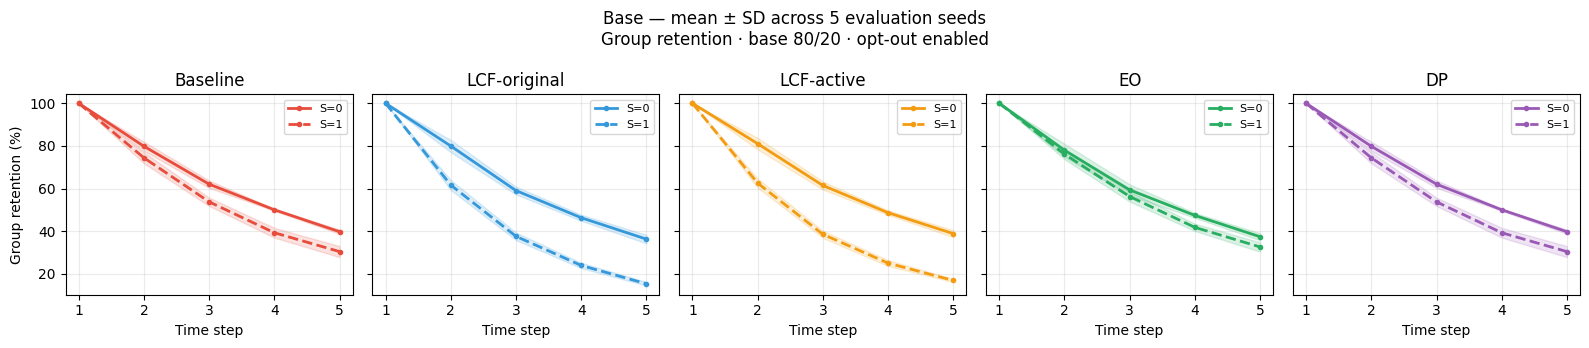

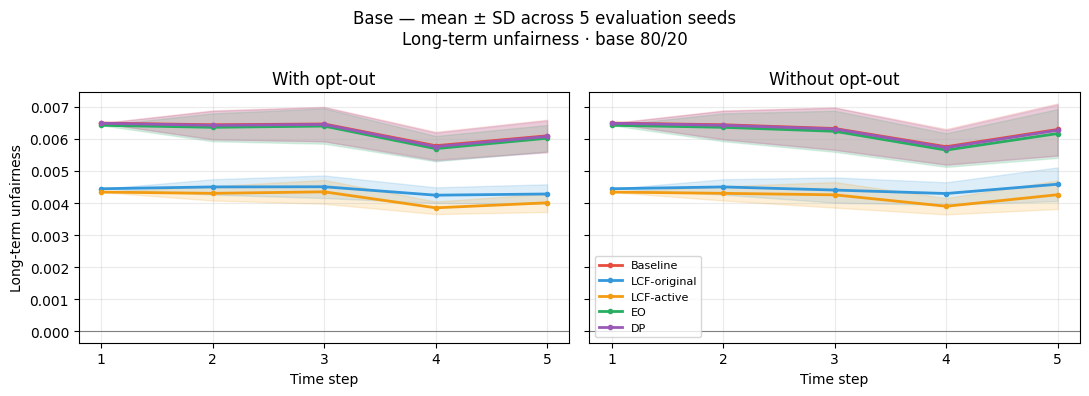

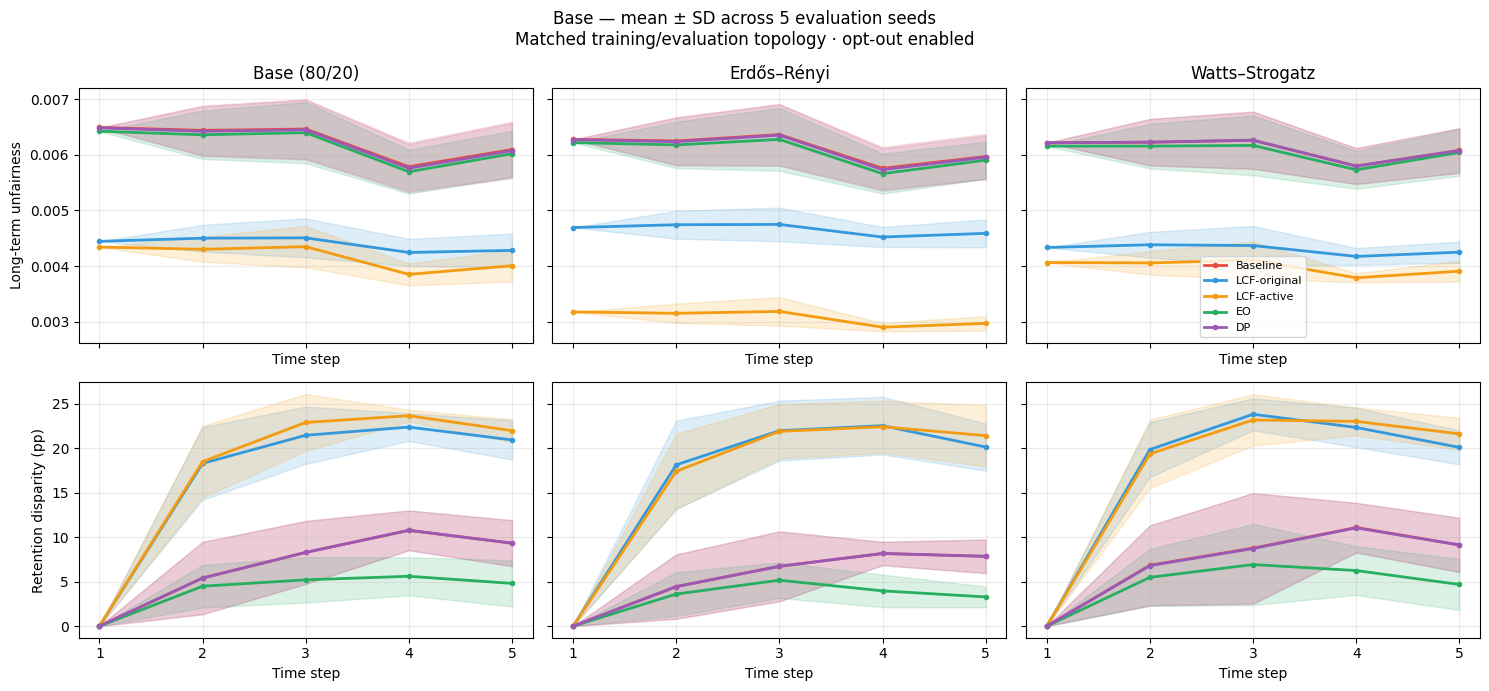

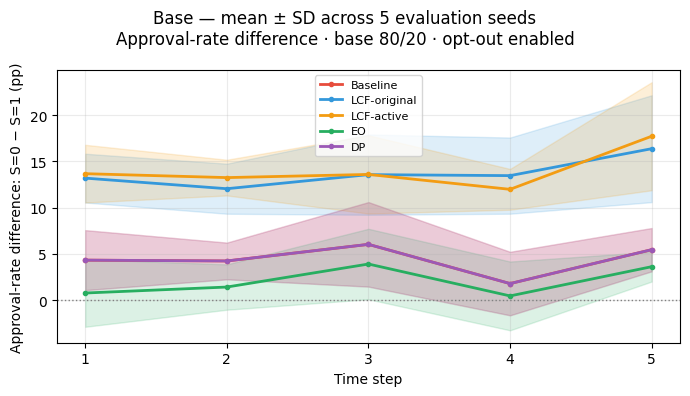

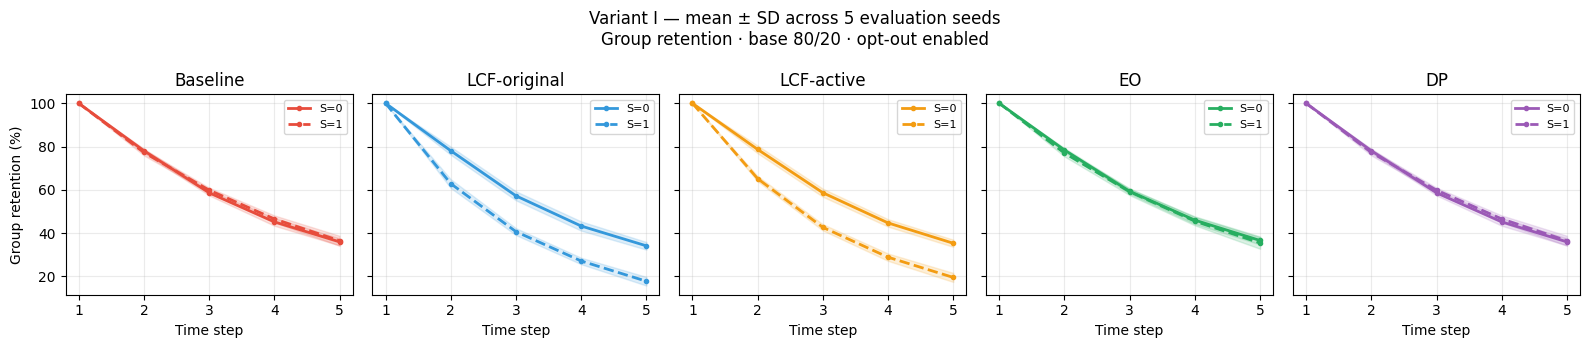

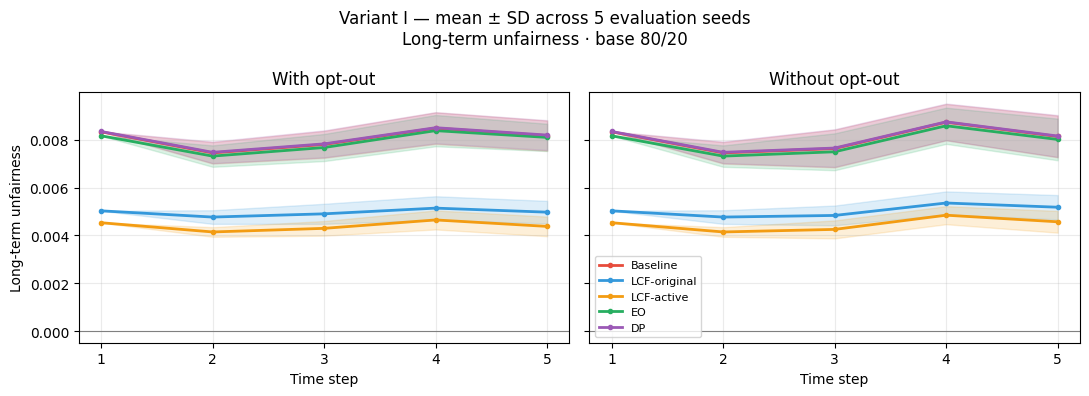

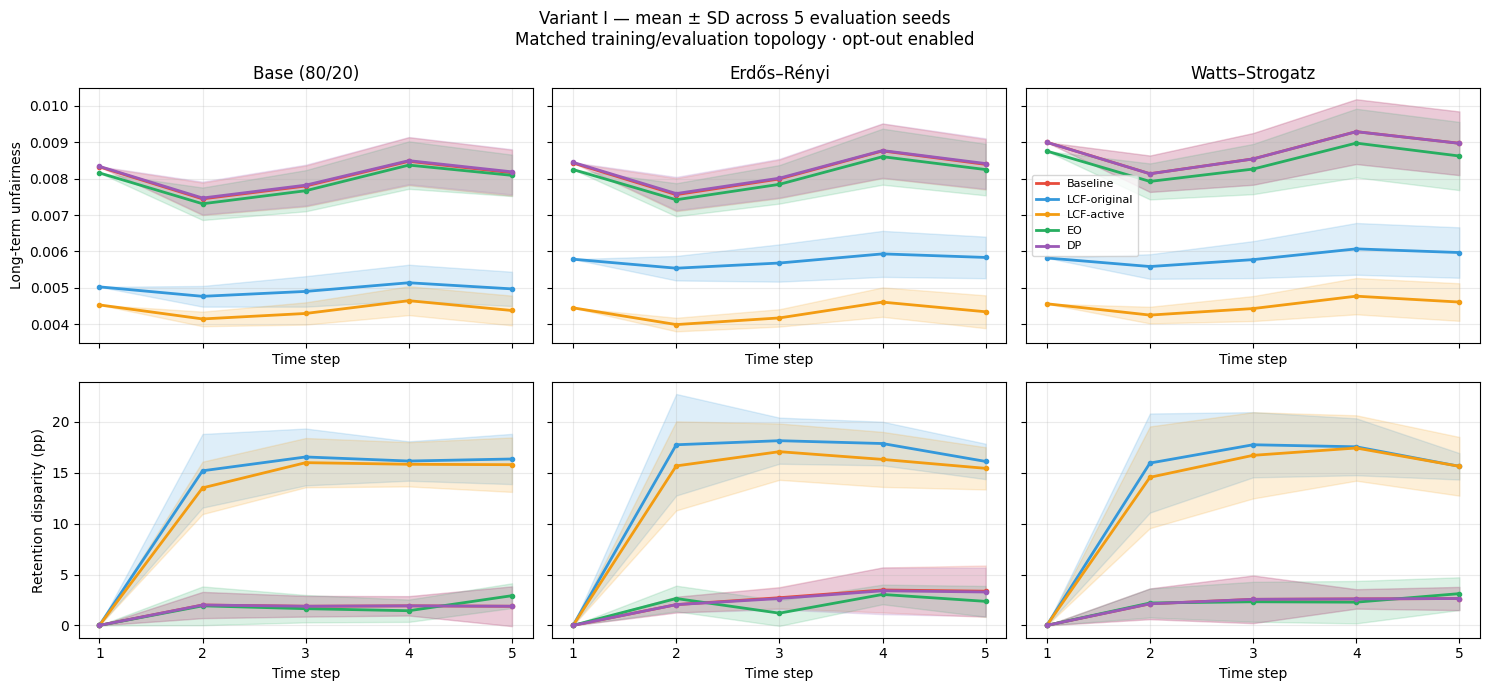

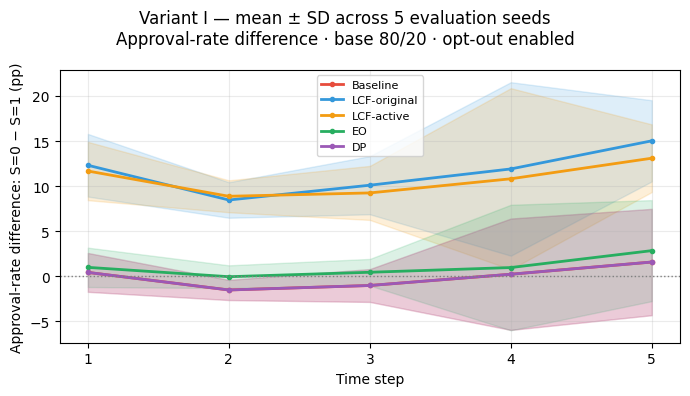

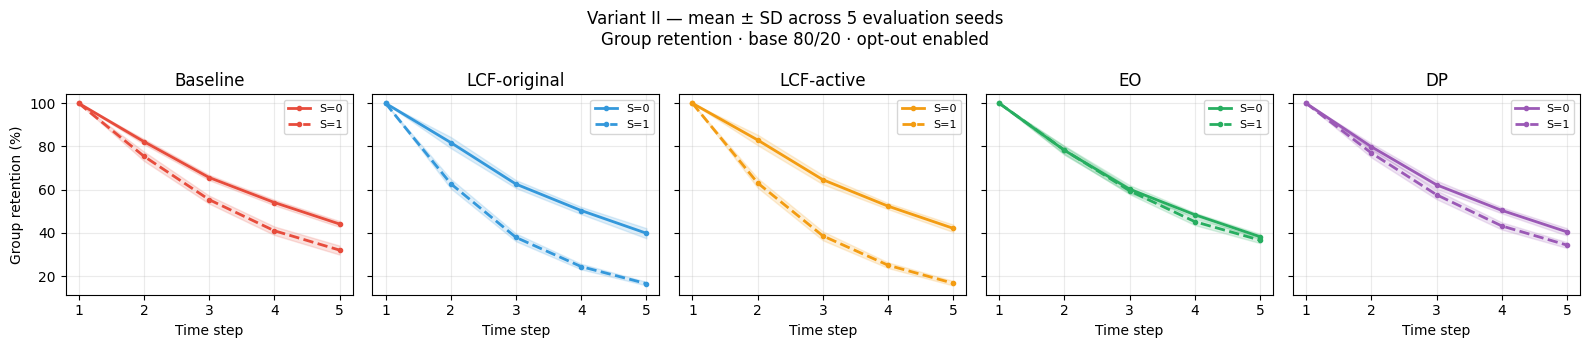

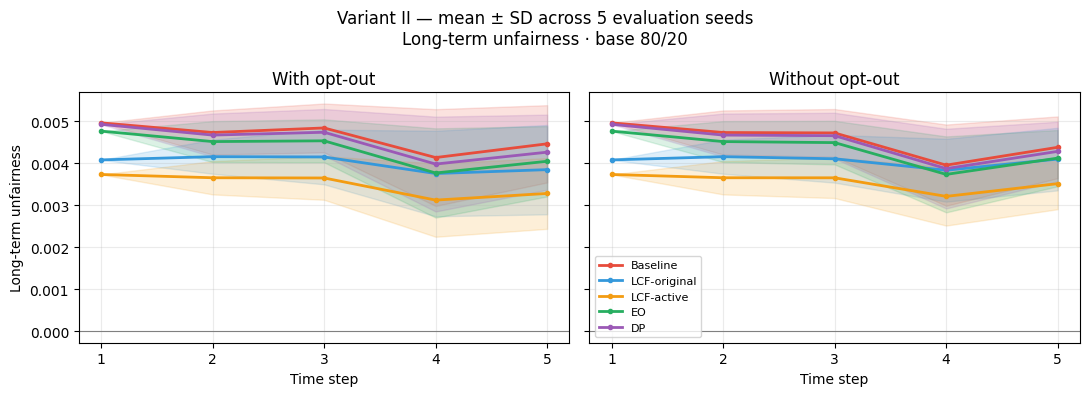

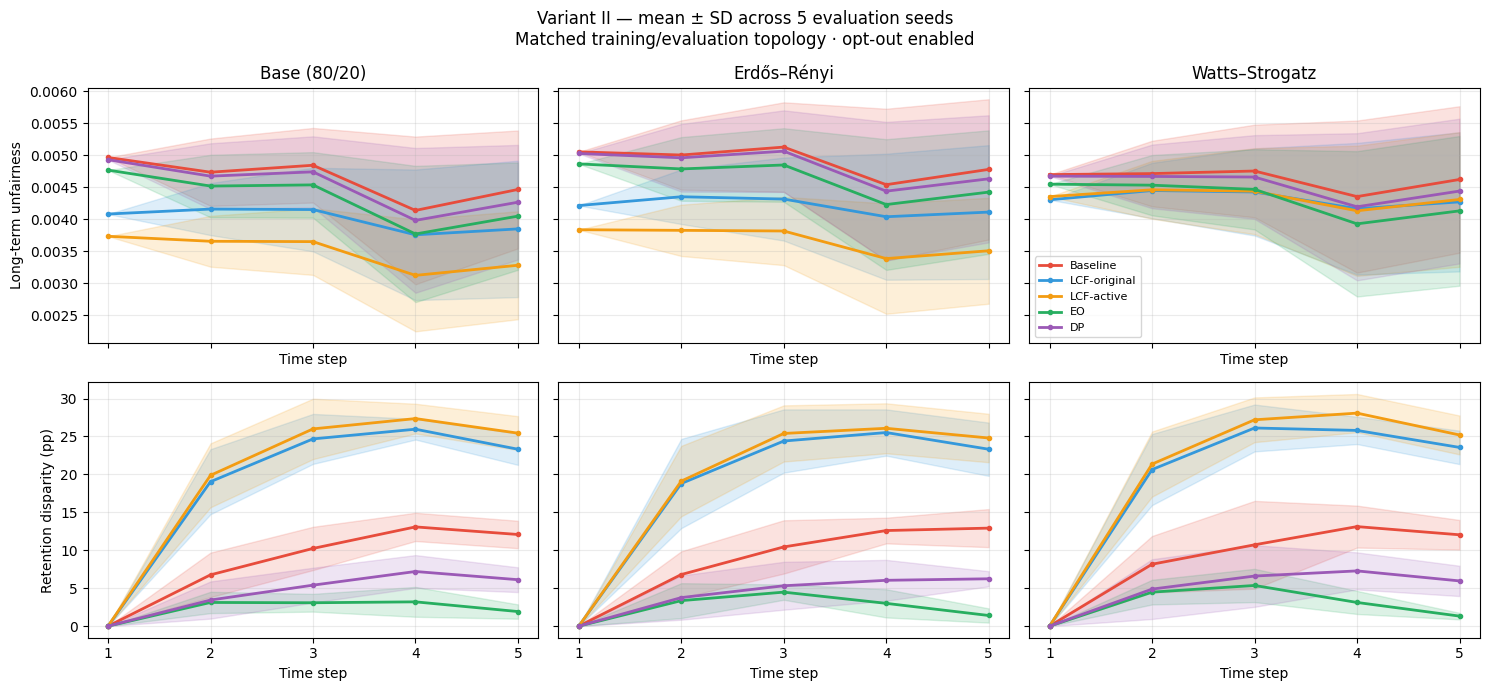

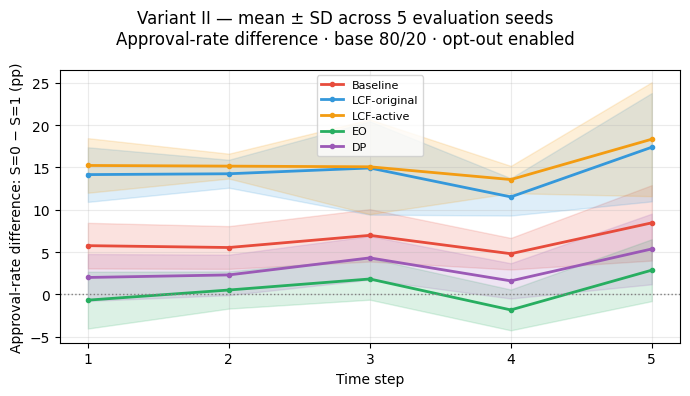

In [33]:
# Every line is a per-step mean across evaluation seeds; shade is mean ± 1 SD.
# Colour always identifies the model. Group and opt-out condition use styles/panels.
MODEL_COLORS = {'Baseline': '#E74C3C', 'LCF-original': '#3498DB',
                'LCF-active': '#F39C12', 'EO': '#27AE60', 'DP': '#9B59B6'}
GROUP_STYLES = {'retention_s0': '-', 'retention_s1': '--'}
PLOT_METRICS = ['retention_s0', 'retention_s1', 'unfairness',
                'retention_disparity', 'approval_rate_difference']
PLOT_KEYS = ['dataset', 'network', 'model', 'opt_out', 'step']
run_results.folder.mkdir(parents=True, exist_ok=True)

# Save the exact statistics underlying all four figure types, including valid seed counts.
plot_long = network_results.melt(id_vars=PLOT_KEYS + ['seed'], value_vars=PLOT_METRICS,
                                 var_name='metric', value_name='value')
if plot_long.duplicated(PLOT_KEYS + ['seed', 'metric']).any():
    raise ValueError('Duplicate seed/step records would distort the plot summaries')
plot_statistics = (plot_long.groupby(PLOT_KEYS + ['metric'], as_index=False)
                   .agg(mean=('value', 'mean'), std=('value', lambda x: x.std(ddof=0)),
                        n_valid_seeds=('value', 'count')))
plot_statistics.to_csv(run_results.folder / 'stepwise_plot_statistics.csv',
                       index=False, float_format='%.17g')

# Remove superseded figures from this run only, including their manifest entries.
obsolete_plots = {'group_retention', 'group_retention_and_ratio', 'long_term_unfairness_merged',
                  'unfairness_with_opt_out', 'unfairness_without_opt_out', 'relative_retention',
                  'approval_rate_difference', 'relative_gradient_retention', 'network_robustness'}
for stem, entry in list(run_results.figures.items()):
    if entry['plot'] in obsolete_plots:
        for filename in entry['files']:
            (run_results.folder / filename).unlink(missing_ok=True)
        del run_results.figures[stem]


def mean_sd_line(ax, data, metric, model, *, label=None, linestyle='-'):
    summary = data[(data['metric'] == metric) & (data['model'] == model)].sort_values('step')
    if summary['step'].duplicated().any():
        raise ValueError('Select exactly one dataset, topology, and opt-out condition per line')
    x, mean, std = (summary[column].to_numpy() for column in ('step', 'mean', 'std'))
    colour = MODEL_COLORS[model]
    ax.plot(x, mean, color=colour, linestyle=linestyle, linewidth=2,
            marker='o', markersize=3, label=label or model)
    ax.fill_between(x, mean - std, mean + std, color=colour, alpha=0.16)
    ax.set(xlabel='Time step', xticks=range(1, NETWORK_STEPS + 1))
    ax.grid(alpha=0.25)


def save_stepwise_figure(fig, dataset, name):
    fig.tight_layout()
    stem = dataset.lower().replace(' ', '_') + '__' + name + '__multiseed'
    files = []
    for extension in ('png', 'pdf'):
        filename = f'{stem}.{extension}'
        fig.savefig(run_results.folder / filename, dpi=300, bbox_inches='tight')
        files.append(filename)
    run_results.figures[stem] = dict(dataset=dataset, plot=name, seeds=list(NETWORK_SEEDS),
        statistic='stepwise mean ± population SD', std_ddof=0,
        statistics_file='stepwise_plot_statistics.csv', files=files)
    plt.show()
    plt.close(fig)


for dataset in experiments:
    methods = list(experiments[dataset]['models'])
    selected = plot_statistics[plot_statistics['dataset'] == dataset]
    base = selected[selected['network'] == 'Base (80/20)']
    active_base = base[base['opt_out']]
    subtitle = f'{dataset} — mean ± SD across {len(NETWORK_SEEDS)} evaluation seeds'

    # 1. Group retention: same model colour as every other figure; group uses line style.
    fig, axes = plt.subplots(1, len(methods), figsize=(3.2 * len(methods), 3.5),
                             sharey=True, squeeze=False)
    for ax, model in zip(axes[0], methods):
        for metric, group in [('retention_s0', 'S=0'), ('retention_s1', 'S=1')]:
            mean_sd_line(ax, active_base, metric, model, label=group,
                         linestyle=GROUP_STYLES[metric])
        ax.set_title(model)
        ax.legend(fontsize=8)
    axes[0, 0].set_ylabel('Group retention (%)')
    fig.suptitle(subtitle + '\nGroup retention · base 80/20 · opt-out enabled')
    save_stepwise_figure(fig, dataset, 'group_retention_stepwise')

    # 2. Unfairness with/without opt-out: identical model colours and shared y scale.
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
    for ax, opt_out, title in zip(axes, (True, False), ('With opt-out', 'Without opt-out')):
        condition = base[base['opt_out'] == opt_out]
        for model in methods:
            mean_sd_line(ax, condition, 'unfairness', model)
        ax.set_title(title)
        ax.axhline(0, color='gray', linewidth=0.8)
    axes[0].set_ylabel('Long-term unfairness')
    axes[1].legend(fontsize=8)
    fig.suptitle(subtitle + '\nLong-term unfairness · base 80/20')
    save_stepwise_figure(fig, dataset, 'unfairness_opt_out_stepwise')

    # 3. Topology comparison: columns are networks, rows are stepwise metrics.
    fig, axes = plt.subplots(2, len(NETWORK_CONFIGS),
                             figsize=(5 * len(NETWORK_CONFIGS), 7),
                             sharex=True, sharey='row', squeeze=False)
    for column, network in enumerate(NETWORK_CONFIGS):
        data = selected[(selected['network'] == network) & selected['opt_out']]
        for row, metric, ylabel in [(0, 'unfairness', 'Long-term unfairness'),
                                    (1, 'retention_disparity', 'Retention disparity (pp)')]:
            ax = axes[row, column]
            for model in methods:
                mean_sd_line(ax, data, metric, model)
            if row == 0:
                ax.set_title(network)
            if column == 0:
                ax.set_ylabel(ylabel)
    axes[0, -1].legend(fontsize=8)
    fig.suptitle(subtitle + '\nMatched training/evaluation topology · opt-out enabled')
    save_stepwise_figure(fig, dataset, 'topology_comparison_stepwise')

    # 4. Signed approval-rate difference among active applicants.
    fig, ax = plt.subplots(figsize=(7, 4))
    for model in methods:
        mean_sd_line(ax, active_base, 'approval_rate_difference', model)
    ax.axhline(0, color='gray', linestyle=':', linewidth=1)
    ax.set_ylabel('Approval-rate difference: S=0 − S=1 (pp)')
    ax.legend(fontsize=8)
    fig.suptitle(subtitle + '\nApproval-rate difference · base 80/20 · opt-out enabled')
    save_stepwise_figure(fig, dataset, 'approval_difference_stepwise')


## Save the complete run: figures, numerical results, and settings

`all_results.csv` contains per-seed metrics and the exact per-step means/SDs underlying the retained figures (`source=figure_stepwise_summary`). `stepwise_plot_statistics.csv` also records valid seed counts. Settings, colour mappings, and topology-specific fitted parameters are recorded in `run_metadata.json` and its identical `mata.json` copy. Export reuses results without retraining. Per-run `README.txt` files are removed after export.


In [34]:
# Metadata uses the actual fitted objects and training arguments from this run.
def describe_object(obj, names):
    return {name: getattr(obj, name) for name in names if hasattr(obj, name)}

import inspect
import hashlib
source_split_defaults = {key: value.default for key, value in
    inspect.signature(split_feature_pools).parameters.items()
    if value.default is not inspect.Parameter.empty}
code_files = [src_path.parents[1] / "local" / "BAF_refactor.ipynb", *sorted(src_path.glob("*.py"))]
run_metadata = dict(
    source_split_defaults=source_split_defaults,
    code_sha256={str(path.relative_to(src_path.parents[1])):
                 hashlib.sha256(path.read_bytes()).hexdigest() for path in code_files},
    notebook="local/BAF_refactor.ipynb", random_seed=RANDOM_SEED,
    simulation_defaults=SIMULATION_SETTINGS,
    plotting=dict(model_colors=MODEL_COLORS, group_styles=GROUP_STYLES,
        statistics='stepwise mean ± population SD', std_ddof=0,
        seeds=NETWORK_SEEDS, data_file='stepwise_plot_statistics.csv'),
    network_robustness=dict(configs=NETWORK_CONFIGS, seeds=NETWORK_SEEDS,
        steps=NETWORK_STEPS, protocol='train and evaluate on matching topology',
        networkx_version=nx.__version__, datasets={}),
    fairness_denominator_clip=FAIRNESS_CLIP,
    decision_policy="Bernoulli(model_probability)",
    fairness_policy="model_probability",
    conditional_ratio_labels="repayment_Y",
    groups={"S=0": "customer_age < 50", "S=1": "customer_age >= 50"},
    feature_order=["credit_risk_score", "proposed_credit_limit"],
    credit_limit_coupling=dict(
        coefficients=credit_limit_coupling.model.coef_,
        intercept=credit_limit_coupling.model.intercept_,
        residual_std=credit_limit_coupling.residual_std,
        fitted_on="Base training partition"),
    datasets={},
)
for dataset_name, experiment in experiments.items():
    train_agent, test_agent = experiment['train_agent'], experiment['test_agent']
    run_metadata['datasets'][dataset_name] = dict(
        input_file=str(datasets_paths[dataset_name]),
        input_size_bytes=datasets_paths[dataset_name].stat().st_size,
        input_modified_ns=datasets_paths[dataset_name].stat().st_mtime_ns,
        train_agent=describe_object(train_agent, ['n_samples', 'seed', 'eps', 'base', 'protect_ratio']),
        test_agent=describe_object(test_agent, ['n_samples', 'seed', 'eps', 'base', 'protect_ratio']),
        training=train_agent.training_settings,
        scaler=describe_object(train_agent.scaler, ['mean_', 'scale_']),
        bank_parameters=experiment['bank'].params,
        models={name: dict(class_name=type(model).__name__,
            **describe_object(model, ['params', 'lr', 'l2_reg', 'sf_reg', 'lf_reg', 'tao', 'probability_clip']),
            sklearn_parameters=(model.model.get_params() if hasattr(model, 'model')
                                and hasattr(model.model, 'get_params') else None))
            for name, model in experiment['models'].items()},
    )

# Record actual network parameters at each population size, plus all fitted policies.
def describe_network(config, agent):
    description = dict(config, n_nodes=agent.n_samples, graph_static_within_trajectory=True)
    if config.get('graph_model') == 'erdos_renyi':
        description.update(p=config['k'] / (agent.n_samples - 1),
                           p_rule='k / (n_nodes - 1)', group_blind=True)
    elif config.get('graph_model') == 'watts_strogatz':
        description.update(ring_assignment='random permutation independent of group', group_blind=True)
    return description


for dataset, by_network in network_experiments.items():
    run_metadata['network_robustness']['datasets'][dataset] = {}
    for network, experiment in by_network.items():
        config = NETWORK_CONFIGS[network]
        training = dict(experiment['train_agent'].training_settings, network_config=config)
        run_metadata['network_robustness']['datasets'][dataset][network] = dict(
            training_network=describe_network(config, experiment['train_agent']),
            evaluation_network=describe_network(config, experiment['test_agent']),
            training=training,
            training_graph_seeds=dict(initial=training['initial_trajectory_seed'],
                retraining=list(range(training['retraining_seed_start'],
                    training['retraining_seed_start'] + training['lcf_retraining_rounds']))),
            evaluation_graph_seeds=list(NETWORK_SEEDS),
            models={name: dict(class_name=type(model).__name__,
                **describe_object(model, ['params', 'lr', 'l2_reg', 'sf_reg', 'lf_reg', 'tao', 'probability_clip']),
                sklearn_parameters=(model.model.get_params() if hasattr(model, 'model')
                                    and hasattr(model.model, 'get_params') else None))
                for name, model in experiment['models'].items()},
        )

# The shared exporter labels experiment metrics as single-seed figure arrays.
# They remain numerical diagnostics, but the plotted arrays now come from all seeds.
export_experiments = {
    dataset: {**experiment, 'metrics': {}, 'metrics_no_opt_out': {}, 'detailed_metrics': {}}
    for dataset, experiment in experiments.items()
}
run_results.rows = {key: row for key, row in run_results.rows.items()
                    if not row.get('source', '').startswith('figure_')}
for row in plot_statistics.to_dict('records'):
    context = {key: row[key] for key in ('dataset', 'network', 'model', 'opt_out')}
    unit = ('percent' if row['metric'].startswith('retention_s') else
            'percentage_points' if row['metric'] in ('retention_disparity', 'approval_rate_difference')
            else 'fraction')
    for statistic in ('mean', 'std'):
        run_results.add(context, 'figure_stepwise_summary', row['metric'], row[statistic],
                        step=row['step'], statistic=statistic, unit=unit,
                        n_valid_seeds=row['n_valid_seeds'], std_ddof=0)
all_results_table = run_results.export(
    export_experiments, extract_metrics, compute_detailed_metrics, run_metadata)
print(f"Saved {len(all_results_table):,} numerical results to {run_results.folder / 'all_results.csv'}")
print(f"Saved {len(run_results.figures)} figures in PNG and PDF, plus run_metadata.json, in the same folder.")
# Keep the requested metadata filename as an exact copy of the complete run metadata.
(run_results.folder / 'mata.json').write_bytes((run_results.folder / 'run_metadata.json').read_bytes())
# The shared exporter creates README.txt; this notebook removes it for every run.
for readme_path in (src_path.parents[1] / 'local' / 'results').rglob('README.txt'):
    readme_path.unlink()


Saved 40,650 numerical results to /Users/jh22215/Documents/GitHub/Delayed-Fairness-Project/local/results/20260917T170632_004886Z_9d3261/all_results.csv
Saved 12 figures in PNG and PDF, plus run_metadata.json, in the same folder.
